<img style="float: left;padding: 1.3em" src="https://indico.in2p3.fr/event/18313/logo-786578160.png">  

#  Gravitational Waves


#### Tutorial : processing a gravitational wave event

This notebook accompanies the lab script for the stage 3 lab, and makes use of data and resources provided by the [Gravitational-Wave Open Science Center (GWOSC)](https://www.gw-openscience.org).

In this notebook you will see examples of how to :
- search for an event
- read an event
- plot a timeseries
- fourier transform the time series to a frequency series
- plot a spectrogram
- make a Q transform
- generate a model waveform
- locate a signal within noise

All of these processes give you an insight into the mechanisms via which gravitational waves are detected by an interferometer. There are questions and investigations within the notebook (presented in blue) to complete as part of the lab, and then a more open-ended investigation at the end. 
    

In [1]:
# -- Uncomment following line if running in Google Colab
#! pip install -q 'gwosc==0.5.4'

In [1]:
import gwosc

The gwosc package provides an interface to querying the open data releases hosted on https://gw-openscience.org from the GEO, LIGO, and Virgo gravitational-wave observatories.

If the package did not successfully install, check the steps in [Software Setup Instructions](https://github.com/gw-odw/odw-2021/blob/master/setup.md).

## Searching for an event

The module `gwosc.datasets` provides tools for searching for datasets, including events, catalogs and full run strain data releases.


For example, we can search for events in the [GWTC-1 catalog](https://www.gw-openscience.org/eventapi/html/GWTC-1-confident/), the catalog of all events from the O1 and O2 observing runs. A list of available catalogs can be seen in the [Event Portal](https://gw-openscience.org/eventapi). The Gravitational-wave Transient Catalog (GWTC) is a cumulative set of gravitational wave transients maintained by the LIGO/Virgo/KAGRA collaboration. The online GWTC contains confidently-detected events from multiple data releases, as well as marginal events and discovery papers. 

In [3]:
from gwosc.datasets import find_datasets
from gwosc import datasets

#-- List all available catalogs
print("List of available catalogs")
print(find_datasets(type="catalog"))
print("")

#-- Print all the GW events from the GWTC-1 catalog
gwtc1 = datasets.find_datasets(type='events', catalog='GWTC-1-confident')
print('GWTC-1 events:', gwtc1)
print("")

List of available catalogs
['GWTC', 'GWTC-1-confident', 'GWTC-1-marginal', 'GWTC-2', 'GWTC-2.1-auxiliary', 'GWTC-2.1-confident', 'GWTC-2.1-marginal', 'GWTC-3-confident', 'GWTC-3-marginal', 'Initial_LIGO_Virgo', 'O1_O2-Preliminary', 'O3_Discovery_Papers', 'O3_IMBH_marginal', 'O4_Discovery_Papers']

GWTC-1 events: ['GW150914-v3', 'GW151012-v3', 'GW151226-v2', 'GW170104-v2', 'GW170608-v3', 'GW170729-v1', 'GW170809-v1', 'GW170814-v3', 'GW170817-v3', 'GW170818-v1', 'GW170823-v1']



We can look within a specific catalog for event files. Event files are named as Gravitational Wave (GW) followed by a sequence of numbers describing the date of the observation (YYMMDD) and the version (v) of the file.

`datasets.find_datasets` also accepts a `segment` and `detector` keyword to narrow results based on GPS time and detector:

In [4]:
#-- Detector and segments keywords limit search result
print(datasets.find_datasets(type='events', catalog='GWTC-1-confident', detector="L1", segment=(1164556817, 1187733618)))

['GW170104-v2', 'GW170608-v3', 'GW170729-v1', 'GW170809-v1', 'GW170814-v3', 'GW170817-v3', 'GW170818-v1', 'GW170823-v1']


The detector here refers to the LIGO-Livingstone interferometer (L1). We could have chosen any of

- G1 - GEO600

- H1 - LIGO-Hanford

- L1 - LIGO-Livingston

- V1 - (Advanced) Virgo

- K1 - KAGRA 

and segment is specified by the number of seconds since Jan 6, 1980 GMT.

If we know the event identifier but not the time, we can use `gwosc.datasets.event_gps` to find the GPS time

In [2]:
from gwosc.datasets import event_gps
gps = event_gps('GW190425')
print(gps)

1240215503.0


## Querying for data files

The `gwosc.locate` module provides a function to find the URLs of data files associated with a given dataset. This means you don't have to download the data directly onto your computer from the archive and you can load it directly into python from the URL.

For event datasets, you can get the list of URLs associated with a given event using only the event name and the `get_event_urls()` function:

In [6]:
from gwosc.locate import get_event_urls
urls = get_event_urls('GW150914')
print(urls)

['http://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5', 'http://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5', 'http://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5', 'http://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/L-L1_GWOSC_4KHZ_R1-1126257415-4096.hdf5']


This will return all the files for that event. If you want to filter this by conditions such as the interferometer used, or length of the file, these can be set as key-word arguments within the function:

In [7]:
urls = get_event_urls('GW150914', duration=32, detector='L1')
print(urls)

['http://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5']


Now we've seen how to query and locate existing data, we can start to read some into python to start our investigations. 

First, we need to choose an event to look at. Let's start with GW190412, since this was the first detection of a gravitational-wave signal from an unequal-mass BBH (binary black hole system).

We can use the `TimeSeries.fetch_open_data` method to download data directly from https://www.gw-openscience.org, but this method requires the input of a GPS time, rather than event name. We've already seen how to find the time of an event:

In [8]:
gps = event_gps('GW190412')
print(gps)

1239082262.1


We want to build a segment or range of time encompassing this value, so that we can look at the data just before and just after the event. We will look at 10 seconds of data in total:

In [9]:
segment = (int(gps)-5, int(gps)+5)
print(segment)

(1239082257, 1239082267)


'segment' therefore defines the start and finish times of the section of data we will look at. We can now query for the full data: 

In [3]:
from gwpy.timeseries import TimeSeries
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)
print(ldata)

/home/val/anaconda3/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


NameError: name 'segment' is not defined

The required parameter inputs for `Timeseries.fetch_open_data` are the detector, and the start and stop times. Other optional arguments include the version (V) of the event file and the sample rate.

We have now downloaded real LIGO data for GW190412! These are the actual data used in the analysis that discovered the first binary black hole merger.

To get a first look at the data we can easily make a plot:

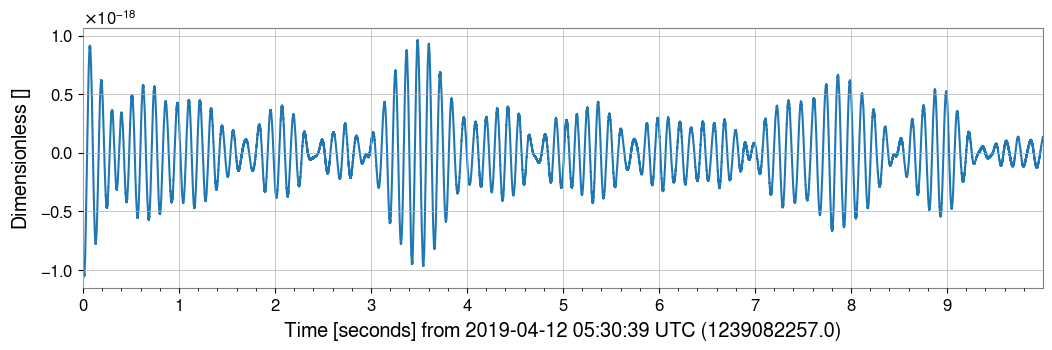

In [11]:
plot = ldata.plot()

The y axis is a dimensionless parameter called the strain. The x axis shows us the ten seconds we specified for the segment. 

Believe it or not, there is a gravitational wave signal in there somewhere. It's clearly not visible in the time domain, so let's move to the frequency domain.

## Fourier transforming the data

The Fourier transform is a widely-used mathematical tool to shift from the time domain to the frequency domain. The noise in the detectors can most easily be characterised in the frequency domain by exposing the frequencies which contain lots of power.

We will perform a fast Fourier transform (FFT) on our timeseries using the `fft()` function:

In [12]:
fft = ldata.fft()
print(fft)

FrequencySeries([-1.45894410e-21+0.00000000e+00j,
                 -2.91834926e-21-4.52905657e-23j,
                 -2.91973330e-21-9.06202944e-23j, ...,
                 -2.38723982e-23+4.67871178e-26j,
                 -2.38345362e-23+1.80394058e-26j,
                 -2.38457175e-23+0.00000000e+00j]
                unit: dimensionless,
                f0: 0.0 Hz,
                df: 0.1 Hz,
                epoch: 1239082257.0,
                name: Strain,
                channel: None)


We can see that we now have a frequency series, rather than a time series. Let's plot the data:

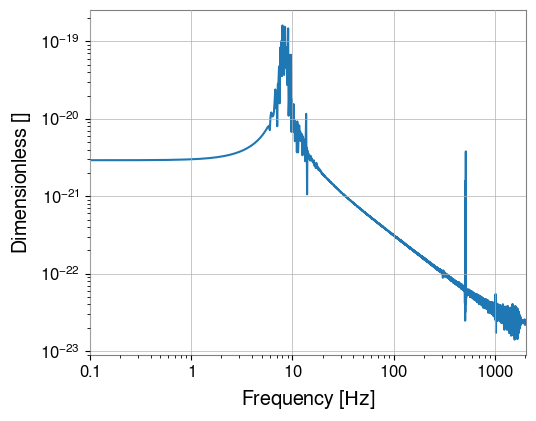

In [13]:
plot = fft.abs().plot(xscale="log", yscale="log")
plot.show(warn=False)

Above we have a log-log plot of the frequency - strain relationship. Our Fourier transform will produce frequency values with a complex amplitude, representing the amplitude and phase of each frequency. Therefore we use the `abs()` function to plot only the amplitude. 

This plot is a bit of a mess and doesn't show us anything useful. Since the FFT implicitly assume that the range of data we are tranforming is periodic in time, the edges of our data look like discontinuities when transformed. It also leads to spectral leakage and spurious correlations in the phase between bins. To avoid this, a window function should be applied to our timeseries data before applying the FFT. 

We can do this using the scipy.signal module:

In [14]:
from scipy.signal import get_window
window = get_window('hann', ldata.size)
lwin = ldata * window

fft = lwin.fft()
print(fft)

FrequencySeries([ 1.15266472e-25+0.00000000e+00j,
                  2.30743981e-25+9.79071543e-27j,
                  2.31431336e-25+1.96187030e-26j, ...,
                 -1.68489836e-26+2.57518637e-26j,
                  1.22607943e-26-2.67707656e-27j,
                 -5.59061987e-27+0.00000000e+00j]
                unit: dimensionless,
                f0: 0.0 Hz,
                df: 0.1 Hz,
                epoch: 1239082257.0,
                name: Strain,
                channel: None)


I've chosen a Hann window, however there are arguments for using Tukey or Flattop windows instead. Let's look at our frequency plot of the windowed data:

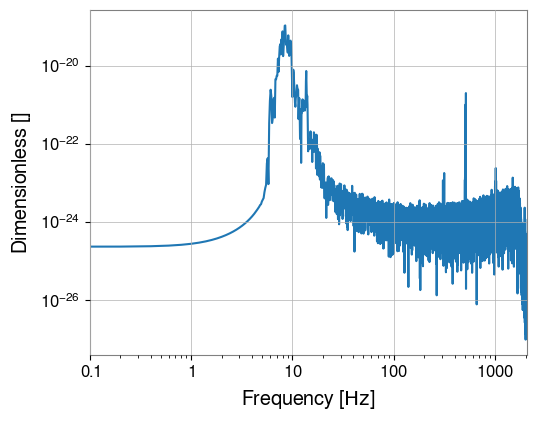

In [15]:
plot = fft.abs().plot(xscale="log", yscale="log")
plot.show(warn=False)

This looks better and shows what we would expect for the amplitude spectral density (ASD) of a gravitational-wave detector.

In practice, it would be better to use a large number of FFTs to estimate an average power spectral density over a much longer period of time. This will average out any random variations. 

We can do this using the `asd()` method, which uses Welch's method to combine FFTs of overlapping, windowed chunks of data. We will load the data into a new file called ldata2 and this time using a segment over 1000 seconds. 

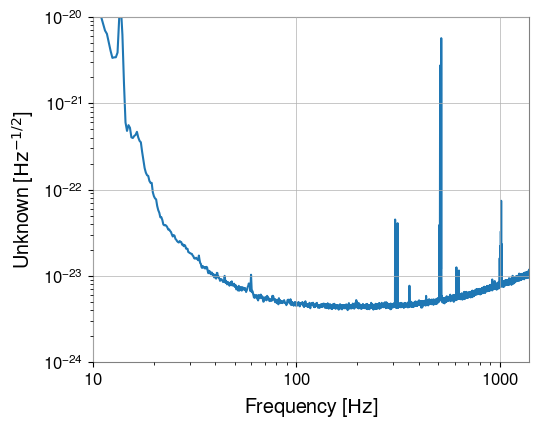

In [16]:
ldata2 = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
lasd2 = ldata2.asd(fftlength=4, method="median")
plot = lasd2.plot()
ax = plot.gca()
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)
plot.show(warn=False)


The ASD is a standard tool used to study the frequency-domain sensitivity of a gravitational-wave detector. We set the fftlength parameter to 4, this is the number of seconds in single a FFT. 

In the plot we can see large spikes at certain frequencies. Some of these spikes are unavoidable noise sources, and others are deliberately introduced to help with interferometer control.

### <span style="color:blue">Task </span>

 <span style="color:blue">1. Compare the ASD from the LIGO Hanford data and VIRGO data to the LIGO Livingstone data for GW190412. Which features are common and which are unique to the observatory? Research common noise sources and their expected frequencies.</span>

## Data representation 

GW data can be represented a variety of different ways, here we will look at spectrograms and Q-tranforms as a way to visualise and interpret data.


The fourier transformed data and the amplitude spectral density we plotted above show us the frequency profile for a single time interval. A spectrogram allows us to look at how this frequency profile evolves with time. It will plot the time-frequency relationship, showing us the ASD across different time steps. This object is a 2-dimensional array, essentially a stacked set of spectra across each time step.

The `TimeSeries` package in GWpy includes two methods to produce a spectrogram:

- spectrogram() - which includes a 'stride' parameter; the step between successives frame in seconds, and shows an averaged ASD every time interval corresponding to each stride.

- spectrogram2() - shows a single-FFT ASD, defined by its fftlength, at each time step. These FFTs can include overlapping segments of tdata, as specified by the overlap parameter.


In general, we use spectrogram2() for short(ish) chunks of data, less than a minute or so, and spectrogram() for longer chunks where the averaging helps remove very short noise bursts.

Let's look at a different GW signal, this time from GW170817. This is the only binary neutron star event that has so far been detected. We will use `spectrogram2()`, and assign the square root of this to specgram. This is because `spectrogram2()` calculates the power spectral density, and we are interested in the amplitude spectral density, which is the square root of this.


GW170817 GPS: 1187008882.4
GW170817 data
TimeSeries([2.06056010e-20, 1.59181918e-20, 2.18438811e-20, ...,
            1.25504332e-19, 1.23976846e-19, 1.22231459e-19]
           unit: dimensionless,
           t0: 1187008370.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)
5.0793933300367376e-27 1 / Hz(1/2) 1.8316206932755355e-19 1 / Hz(1/2)


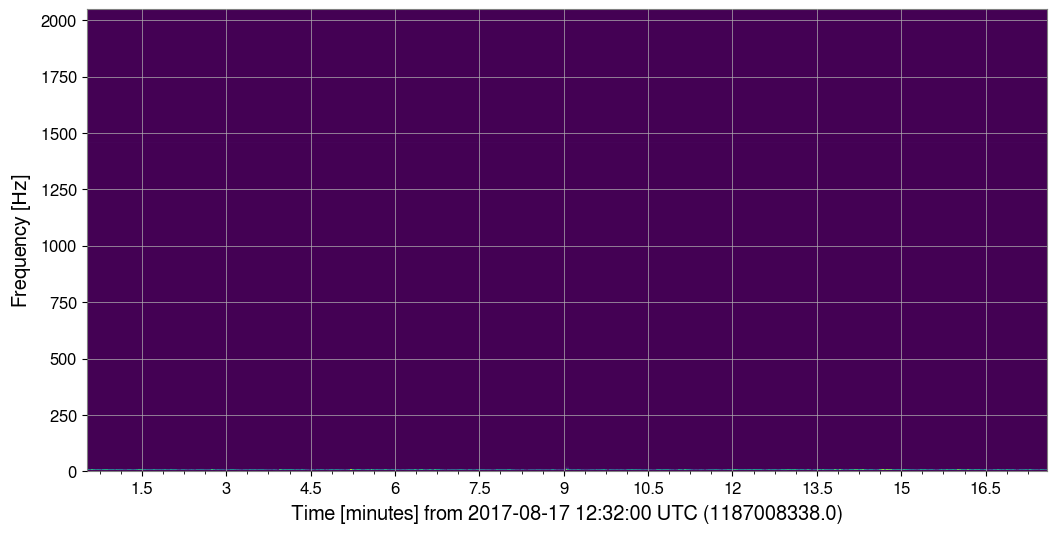

In [6]:
import gwpy
gps = event_gps('GW170817')
print("GW170817 GPS:", gps)

ldata = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
print("GW170817 data")
print(ldata)

specgram = ldata.spectrogram2(fftlength=4, overlap=2, window='hann') ** (1/2.)

print(specgram.min(), specgram.max())

plot = specgram.plot()


It's quite difficult to see anything here, but you may notice a couple of bright pixels around 9 minutes, at low frequencies. Let's rescale our plot with log axes and set the colour bar range.

In [37]:
%matplotlib inline

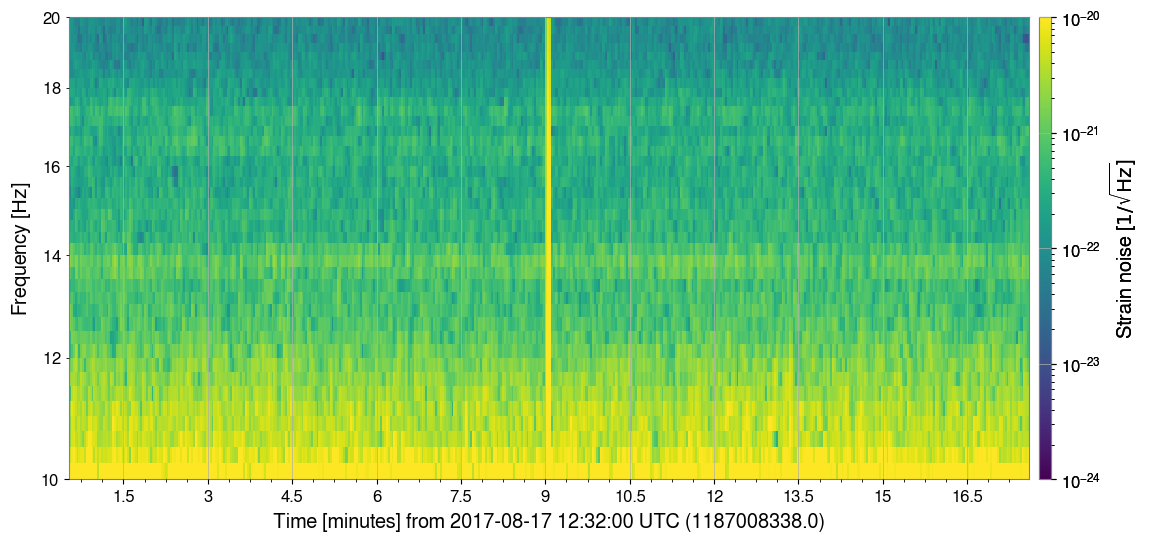

In [8]:
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(10, 20)
ax.colorbar(
   clim=(1e-24, 1e-20),
   norm="log",
   label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]",
)
plot

Here we can see how the ASD for LIGO-Livingston evolves over a ~17 minute span around GW170817. Four order of magnitudes in the ASD intensity are involved, and this is way the previous attempt resulted in a (almost) fully dark blue image.

We can see that the low-frequency noise (<30 Hz) rumbles along with some variation, but high frequencies (>100 Hz) are relatively stable. Between 30-100 Hz we can see some narrow features appearing and disappearing as non-stationary noise affects the measurement.

## Q transforms 

The spectrogram above is a useful way to show the variation of a power spectral density (PSD) estimate over time. It's best used to see general trends in how the sensitivity of the GW detectors is changing over longish periods (minutes or hours).

In this section, we will see how we can use a special filter called a Q-transform to create a time-frequency representation of our data that allows use to pick out features at different frequencies, and how they evolve over very short times, without much prior knowledge of the signal morphology.

See [this link](https://dcc.ligo.org/public/0035/G040521/000/G040521-00.pdf) for more details on the Q-transform and its application to gravitational-wave data.

First, lets reload some data from LIGO Hanford around GW170817:

In [9]:
segment = (int(gps) - 30, int(gps) + 2)
hdata = TimeSeries.fetch_open_data('H1', *segment, verbose=True, cache=True)

Fetched 1 URLs from gwosc.org for [1187008852 .. 1187008884))
Reading data... [Done]


We can now use the q_transform() method of the hdata TimeSeries to create our time-frequency representation (as a spectrogram).

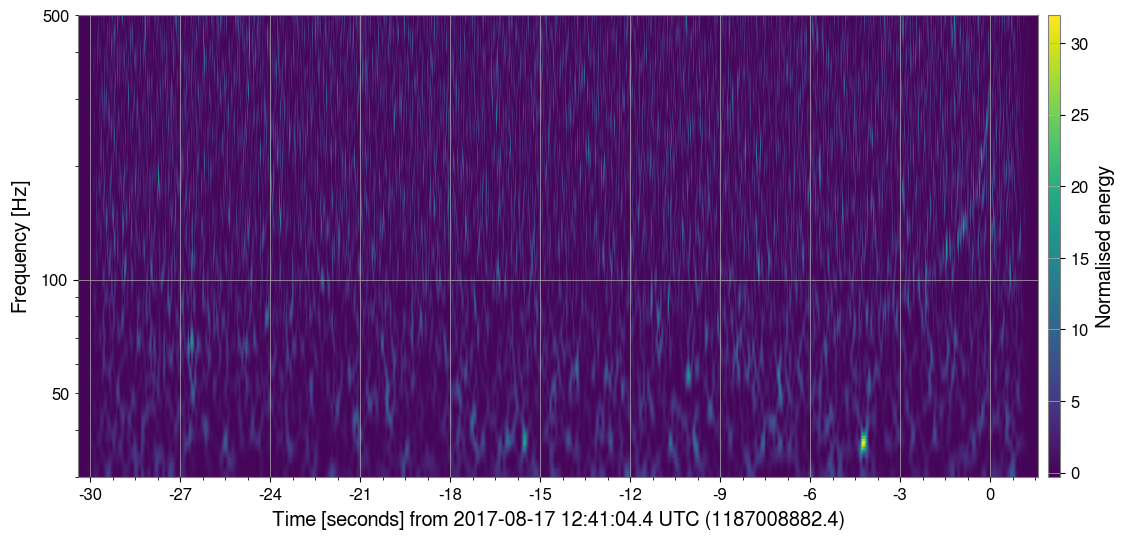

In [10]:
hq = hdata.q_transform(frange=(30, 500))
plot=hq.plot()
ax = plot.gca()
ax.set_epoch(gps)
ax.set_ylim(30, 500)
ax.set_yscale("log")
plot.colorbar(label="Normalised energy")


From this we can see a different representation of the data. Because the Q-transform returns (by default) normalised energy, the low-frequency rumbling is now much less obvious, and we can see better some noises at higher frequencies.


Now we can see a more prominent feature starting at ~-6 seconds that looks a little familiar. Here we can use our knowledge of the Q-transform, and our hunch about the origin of the 'feature' to choose a more specific range of 'Q' for the Q-transform, so as to better resolve the feature:

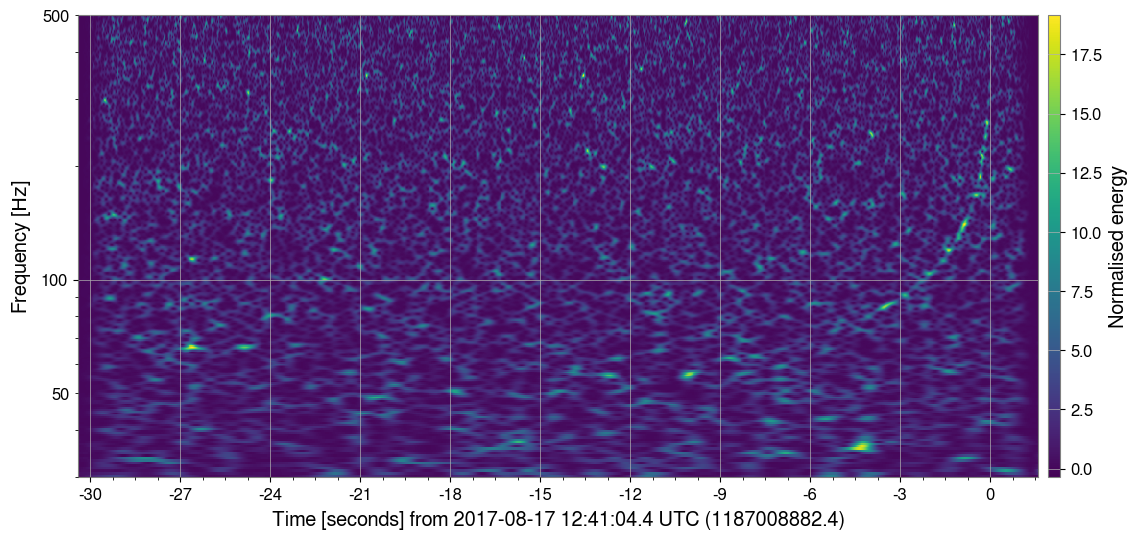

In [11]:
hq = hdata.q_transform(frange=(30, 500), qrange=(100, 110))
plot = hq.plot()
ax = plot.gca()
ax.set_epoch(gps)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")

Now we see the clear track of a BNS merger, visible from about -4 seconds (maybe -10 if you squint), all the way through to the merger at T=0s.

### <span style="color:blue">Task</span>

 <span style="color:blue">2. Download the data for all detectors involved with the GW170814 detection. Which detectors registered this event? Generate a Q-scan for the data in each detector. </span>

## Generating waveforms 

Now we will numerically obtain the gravitational waveform radiated during a compact binary coalescence, assuming the basic parameters of the binary are known.

We will be using the PyCBC library, which provides an easy-to-use Python interface to obtain such waveforms. PyCBC can more generally be used to analyze or simulate gravitational-wave data, find or simulate astrophysical signals from compact binary mergers, and study their parameters. It is one of the tools routinely used by groups within and outside of the LIGO and Virgo collaborations.

If you are using your own computer, you may need to download lalsuite and pycbc - see the guidance docs. Note that lalsuite will not run on Windows machines. These packages are installed on Linux PCs in the physics computer lab. 

In [7]:
from pycbc.waveform import get_td_waveform
import pylab

Here we'll generate the gravitational waveform using one of the available waveform approximants. The waveform can be generated as a time series using get_td_waveform(). There are some additional examples using this interface here. The key parameters are the masses of the binary (given in solar masses), the time between samples (in seconds), the starting gravitational-wave frequency (Hz) and the name of the approximant we'd like to use. A variety of approximants are available that include different physical effects.
In this example, we've chosen to use the 'SEOBNRv4_opt' approximant. This is an implementation of the model introduced in this paper. It models the gravitational waveform of inspiralling and merging black holes, and includes the ability for each black hole to spin in the same direction as the orbit (aligned spin).
There are many other models available, with different methodologies employed and physical effects modelled. A full review of the models is outside of the scope of this tutorial.

In [ ]:
# The outputs of this function are the "plus" and "cross" polarizations 
# of the gravitational-wave signal as viewed from the line of sight at 
# a given source inclination (assumed face-on, i.e. zero inclination
# if not provided)
hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=10,
                         mass2=10,
                         delta_t=1.0/16384,
                         f_lower=30)

pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.plot(hp.sample_times, hc, label='Cross Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.legend()
pylab.grid()
pylab.show()

# Zoom in near the merger time
pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.plot(hp.sample_times, hc, label='Cross Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.xlim(-.01, .01)
pylab.legend()
pylab.grid()
pylab.show()

We can see that in the this case, the two polarizations differ only by the phase of the signal. This is a known property of the signal, when the orbital plane of the binary does not precess (i.e. the individual black holes spins are aligned with the orbital angular momentum). In the zoom-in plot, we can see the merger itself and the ringdown that follows.

### <span style="color:blue">Task </span>
<span style="color:blue">3. How does the waveform change with the mass of the binary? Investigate the waveform for a binary systems with masses 5, 10, 30 and 100 solar masses (where each binary component has the same mass). What if the masses are different? </span>




The luminosity distance of the source, 'distance' is also a parameter within the get_td_waveform function. The units used are Megaparsecs. 

### <span style="color:blue">Task </span>
<span style="color:blue">4. Investigate the relationship between the amplitude of the wave and the distance. What does this relationship not take into account? </span>


<span style="color:blue">5. Calculate and show the Q transform for the LIGO Livingstone data for the GW150914 event. Comment on the observed feature and what it tells you about the expected waveform. </span>
    
<span style="color:blue">6. Generate and plot the waveform associated with the GW150914. Look up the GWTC-1 catalogue page to obtain the estimated parameters for this source. Is it as you expected? </span>

Now that we've seen what the signals should look like, we can look at how to extract it from noise.

## Matched-filtering: Finding well-modelled signals in Gaussian noise

Matched filtering is the optimal method for "detecting" known signals in Gaussian noise. Since the strain amplitude of a GW signal is so small, any noise sources will completely swamp the signal. This section will show how a model signal of a GW event can be extracted from noisy data. 

Let's assume you have a stretch of white noise to start. White noise is a time domain signal made of uncorrelated, Gaussian distributed amplitude spikes. It contains all frequencies in equal proportion and its spectrum (power spectral density is flat. This is analogous to light, which turns white when all frequencies are summed up into a single beam. We can generate a stretch of white noise using the NumPy random.normal function. 

In [4]:
%matplotlib inline
import numpy
import pylab

# LIGO raw data is sampled at 16384 Hz (=2^14 samples/second).
# It captures signal frequencies up to f_Nyquist = 8192 Hz.
# we will make the computation faster by sampling at a lower rate.
sample_rate = 1024 # samples per second
data_length = 1024 # seconds

# Generate a long stretch of white noise: the data series and the time series.
data = numpy.random.normal(size=[sample_rate * data_length])
times = numpy.arange(len(data)) / float(sample_rate)

And then let's add a gravitational wave signal to some random part of this data. This signal comes in the form of the approximant, this time we are using the Inspiral-Merger-Ringdown waveform model called IMRPhenomD. See the documentation on this model for the specific details. 

In [5]:
apx = 'IMRPhenomD'

We will use default parameters for everything except the masses, which we will set to 10 solar masses. We will also only look at the plus polarisation, hp, for now. 

In [8]:
hp1, _ = get_td_waveform(approximant=apx,
                         mass1=10,
                         mass2=10,
                         delta_t=1.0/sample_rate,
                         f_lower=25)

The amplitude of gravitational-wave signals is normally of order 10^-20m. To demonstrate our method on white noise with much larger amplitudes (centred on a mean of 0), we need to normalise our signal so that the cross-correlation of the signal with itself will give a value of 1. In this case we can interpret the cross-correlation of the signal with white noise as a signal-to-noise ratio.

In [9]:
hp1 = hp1 / max(numpy.correlate(hp1, hp1, mode='full'))**0.5

Let's plot the waveform and see what it looks like. You will see that the normalised waveform amplitude is between +-0.1. The waveform is tapered, so it increases slowly to start with and then ramps up to the maximum amplitude within around a second.

Text(0, 0.5, 'Normalised amplitude')

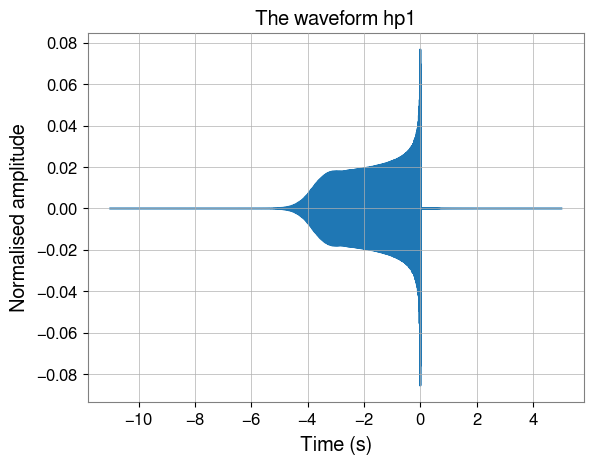

In [10]:
pylab.figure()
pylab.title("The waveform hp1")
pylab.plot(hp1.sample_times, hp1)
pylab.xlabel('Time (s)')
pylab.ylabel('Normalised amplitude')

We've seen what the GW model waveform looks like. Let's shift the signal to some random time within the noise, and plot both the noise and the waveform hidden within the noise. I've multiplied the hp1 amplitude by 10 to make it more obvious.

Text(0, 0.5, 'Normalised amplitude')

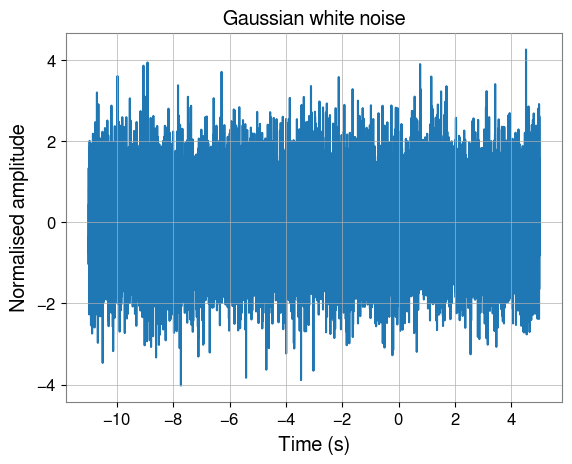

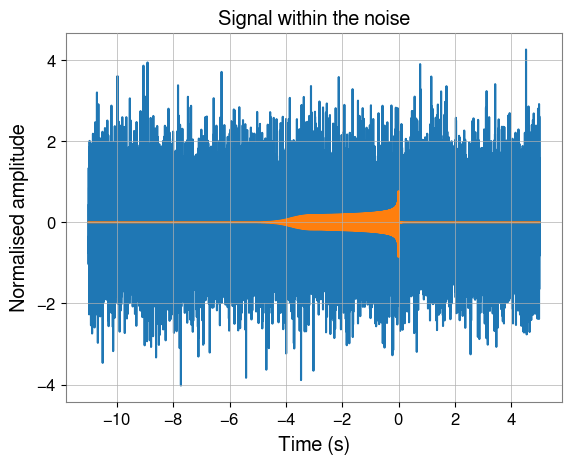

In [11]:
waveform_start = numpy.random.randint(0, len(data) - len(hp1))
data[waveform_start:waveform_start+len(hp1)] += 10*hp1.numpy()

pylab.figure()
pylab.title("Gaussian white noise")
pylab.plot(hp1.sample_times, data[waveform_start:waveform_start+len(hp1)])
pylab.xlabel('Time (s)')
pylab.ylabel('Normalised amplitude')

pylab.figure()
pylab.title("Signal within the noise")
pylab.plot(hp1.sample_times, data[waveform_start:waveform_start+len(hp1)])
pylab.plot(hp1.sample_times, 10* hp1)
pylab.xlabel('Time (s)')
pylab.ylabel('Normalised amplitude')

As you can see, it is impossible to pick out a GW signal from the white noise.

To search for this signal we can cross-correlate the signal with the entire dataset - in the next section we will optimise this technique, but here we introduce the general method. Cross-correlation is a measure of the similarity of two signals, it is commonly used for searching a long signal for a shorter, known feature. 

For example, imagine you had two sinusoidal functions with some phase shift. When the phase shift between the two signals is 0, the cross-correlation is 1 and the signals are identical. When the signals are out of phase by pi, the cross-correlation is -1.

The cross correlation for two discrete functions g(m) and f(m) is defined as:

$$ (f * g) [n] = \sum f[m]g[m+n] $$ 

where $n$ is some displacement or lag. 

We will do the cross-correlation in the time domain, once for each time step. Recall that hp1 is the gravitational wave signal we have added to our white noise dataset 'data'. It runs slowly...

Text(0, 0.5, 'Cross-correlation')

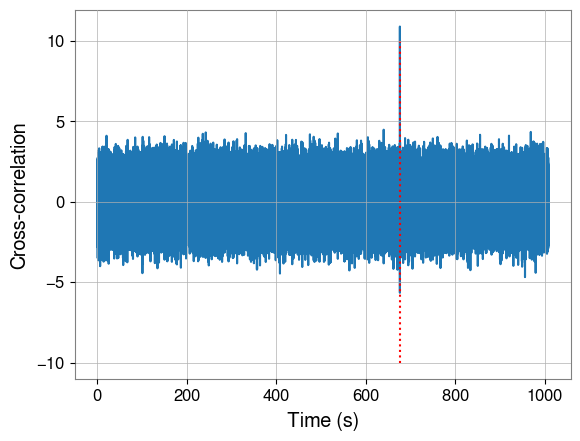

In [12]:
cross_correlation = numpy.zeros([len(data)-len(hp1)])
hp1_numpy = hp1.numpy()
for i in range(len(data) - len(hp1_numpy)):
    cross_correlation[i] = (hp1_numpy * data[i:i+len(hp1_numpy)]).sum()

# plot the cross-correlated data vs time. Superimpose the location of the end of the signal;
# this is where we should find a peak in the cross-correlation.
pylab.figure()
times = numpy.arange(len(data) - len(hp1_numpy)) / float(sample_rate)
pylab.plot(times, cross_correlation)
pylab.plot([waveform_start/float(sample_rate), waveform_start/float(sample_rate)], [-10,10],'r:')
pylab.xlabel('Time (s)')
pylab.ylabel('Cross-correlation')

Here you can see that the largest spike from the cross-correlation comes at the time of the signal. 

### <span style="color:blue">Task </span>

<span style="color:blue">7. Histogram the whitened time series. Ignoring the outliers associated with the signal, is it a Gaussian? What is the mean and standard deviation? (We have not been careful in normalizing the whitened data properly). </span>

<span style="color:blue">8. Find the location of the peak, and the value of the SNR of the signal (which is the absolute value of the peak value, divided by the standard deviation of the cross-correlation time series) </span>

---------

We only really need one more ingredient to describe matched-filtering: "Coloured" noise (Gaussian noise but with a frequency-dependent variance; white noise has frequency-independent variance).

Let's repeat the process, but generate a stretch of data coloured with LIGO's zero-detuned--high-power noise curve. We define the low frequency cut-off as 10 Hz, the frequency width as 1/128 and the frequency length. We'll use a PyCBC library to do this. 

The pycbc.noise.noise_from_psd module creates noise from a given psd, providing the module with the length of noise to generate, the timestep of the noise, the psd i.e. the noise weighting to colour the noise and a seed to generate the noise.

In [13]:
# http://pycbc.org/pycbc/latest/html/noise.html
import pycbc.noise
import pycbc.psd

# The color of the noise matches a PSD which you provide:
# Generate a PSD matching Advanced LIGO's zero-detuned--high-power noise curve 
flow = 10.0
delta_f = 1.0 / 128
flen = int(sample_rate / (2 * delta_f)) + 1
psd = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, flow)

# Generate colored noise
delta_t = 1.0 / sample_rate
ts = pycbc.noise.noise_from_psd(data_length*sample_rate, delta_t, psd, seed=127)

XLAL Error - XLALCreateREAL8FFTPlan (RealFFT_source.c:120): Generic failure
XLAL Error - XLALCreateReverseREAL8FFTPlan (RealFFT_source.c:145): Internal function call failed: Generic failure
XLAL Error - XLALSimNoiseSegment (LALSimNoise.c:50): Internal function call failed: Generic failure


RuntimeError: Internal function call failed: Generic failure

We then estimate the amplitude spectral density (ASD = sqrt(PSD)) for the noisy data using the "welch" method. We'll choose 4 seconds PSD samples that are overlapped 50%

In [14]:

seg_len = int(4 / delta_t)
seg_stride = int(seg_len / 2)
estimated_psd = pycbc.psd.welch(ts,seg_len=seg_len,seg_stride=seg_stride)

# plot it:
pylab.loglog(estimated_psd.sample_frequencies, estimated_psd, label='estimate')
pylab.loglog(psd.sample_frequencies, psd, linewidth=3, label='known psd')
pylab.xlim(xmin=flow, xmax=512)
pylab.ylim(1e-47, 1e-45)
pylab.xlabel('Frequency [Hz]')
pylab.ylabel('Power spectral density')
pylab.legend()
pylab.grid()
pylab.show()

# add the signal, this time, with a "typical" amplitude.
ts[waveform_start:waveform_start+len(hp1)] += hp1.numpy() * 1E-20

NameError: name 'ts' is not defined

Then all we need to do is to "whiten" both the data, and the template waveform. This can be done, in the frequency domain, by dividing by the PSD. This can be done in the time domain as well, but it's more intuitive in the frequency domain

In [ ]:
# Generate a PSD for whitening the data
from pycbc.types import TimeSeries

# The PSD, sampled properly for the noisy data
flow = 10.0
delta_f = 1.0 / data_length
flen = int(sample_rate / (2 * delta_f)) + 1
psd_td = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

# The PSD, sampled properly for the signal
delta_f = sample_rate / float(len(hp1))
flen = int(sample_rate / (2 * delta_f)) + 1
psd_hp1 = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

# The 0th and Nth values are zero. Set them to a nearby value to avoid dividing by zero.
psd_td[0] = psd_td[1]
psd_td[len(psd_td) - 1] = psd_td[len(psd_td) - 2]
# Same, for the PSD sampled for the signal
psd_hp1[0] = psd_hp1[1]
psd_hp1[len(psd_hp1) - 1] = psd_hp1[len(psd_hp1) - 2]

# convert both noisy data and the signal to frequency domain,
# and divide each by ASD=PSD**0.5, then convert back to time domain.
# This "whitens" the data and the signal template. 
# Multiplying the signal template by 1E-21 puts it into realistic units of strain.
data_whitened = (ts.to_frequencyseries() / psd_td**0.5).to_timeseries()
hp1_whitened = (hp1.to_frequencyseries() / psd_hp1**0.5).to_timeseries() * 1E-21

In [ ]:
# Now let's re-do the correlation, in the time domain, but with whitened data and template.
cross_correlation = numpy.zeros([len(data)-len(hp1)])
hp1n = hp1_whitened.numpy()
datan = data_whitened.numpy()
for i in range(len(datan) - len(hp1n)):
    cross_correlation[i] = (hp1n * datan[i:i+len(hp1n)]).sum()

# plot the cross-correlation in the time domain. Superimpose the location of the end of the signal.
# 
pylab.figure()
times = numpy.arange(len(datan) - len(hp1n)) / float(sample_rate)
pylab.plot(times, cross_correlation)
pylab.plot([waveform_start/float(sample_rate), waveform_start/float(sample_rate)],
           [(min(cross_correlation))*1.1,(max(cross_correlation))*1.1],'r:')
pylab.xlabel('Time (s)')
pylab.ylabel('Cross-correlation')

Note how much bigger the cross-correlation peak is, relative to the noise level, compared with the unwhitened version of the same quantity. SNR is much higher!